# Diabates Prediction Classification using Machine Learning

I will be following this framework:
1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition
> The goal is to use machine learning algorithms to classify individuals as diabetic or non-diabetic.

## 2. Data
This is a detailed dataset comprising health and demographic data of 100,000 individuals, aimed at facilitating diabetes-related research and predictive modeling.
I got the dataset from Kaggle - https://www.kaggle.com/datasets/ziya07/diabetes-clinical-dataset100k-rows

## 3. Evaluation
Since this is a classification problem, we will evaluate the model based on `mean accuracy`, `precision`, `recall`, `f1-score`, `AUC (ROC curve)`, `confusion matrix` and `classification report`.

## 4. Features
This dataset comprises 100,000 entries, each representing an individual's health and demographic data pertinent to diabetes research. The dataset includes 17 columns, detailed below:
1. year
2. gender
3. age
4. location
5. race:AfricanAmerican
6. race:Asian
7. race:Caucasian
8. race:Hispanic
9. race:Other
10. hypertension
11. heart_disease
12. smoking_history
13. bmi
14. hbA1c_level
15. blood_glucose_level
16. `diabetes` (target attribute / label)
17. clinical_notes 

In [1]:
# Import the tools needed

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [3]:
diabetes = pd.read_csv("diabetes_dataset_with_notes.csv")
diabetes.T

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
year,2020,2015,2015,2015,2016,2016,2015,2016,2016,2015,...,2016,2016,2016,2016,2016,2018,2016,2018,2018,2016
gender,Female,Female,Male,Male,Female,Male,Female,Female,Male,Male,...,Female,Male,Female,Male,Male,Female,Female,Male,Female,Male
age,32.0,29.0,18.0,41.0,52.0,66.0,49.0,15.0,51.0,42.0,...,33.0,1.48,80.0,58.0,62.0,33.0,80.0,46.0,51.0,13.0
location,Alabama,Alabama,Alabama,Alabama,Alabama,Alabama,Alabama,Alabama,Alabama,Alabama,...,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming,Wyoming
race:AfricanAmerican,0,0,0,0,1,0,0,0,1,0,...,0,0,1,1,0,0,0,0,1,0
race:Asian,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0
race:Caucasian,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
race:Hispanic,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
race:Other,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
hypertension,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
len(diabetes) # 100,000 rows as mentioned

100000

### Exploratory Data Analysis (EDA)

First let's check the basic info for this dataset using `.info()` and `.describe()` and check for missing values for each column using `.isna.sum()`

In [10]:
diabetes.info() # basic info of dataset

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  diabetes    

We can see that we have `100,000` records, `17` columns and `4` attributes (features) have non-numeric values which needs to be handled later.

In [11]:
diabetes.describe().T # info for the numeric columns of the dataset

,count,mean,std,min,25%,50%,75%,max
year,100000.0,2018.360820,1.345239,2015.00,2019.00,2019.00,2019.00,2022.00
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
race:AfricanAmerican,100000.0,0.202230,0.401665,0.00,0.00,0.00,0.00,1.00
race:Asian,100000.0,0.200150,0.400114,0.00,0.00,0.00,0.00,1.00
race:Caucasian,100000.0,0.198760,0.399069,0.00,0.00,0.00,0.00,1.00
race:Hispanic,100000.0,0.198880,0.399160,0.00,0.00,0.00,0.00,1.00
race:Other,100000.0,0.199980,0.399987,0.00,0.00,0.00,0.00,1.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69


In [12]:
diabetes.isna().sum() # check for missing values along each column

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
clinical_notes          0
dtype: int64

There are no missing values for each column, so just need to convert non-numeric to numeric values!

In [14]:
diabetes.head().T

,0,1,2,3,4
year,2020,2015,2015,2015,2016
gender,Female,Female,Male,Male,Female
age,32.0,29.0,18.0,41.0,52.0
location,Alabama,Alabama,Alabama,Alabama,Alabama
race:AfricanAmerican,0,0,0,0,1
race:Asian,0,1,0,0,0
race:Caucasian,0,0,0,1,0
race:Hispanic,0,0,0,0,0
race:Other,1,0,1,0,0
hypertension,0,0,0,0,0


In [15]:
diabetes["year"].value_counts()

year
2019    79745
2015     8760
2016     8760
2018     2678
2020       42
2022        8
2021        7
Name: count, dtype: int64

In [17]:
diabetes["gender"].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

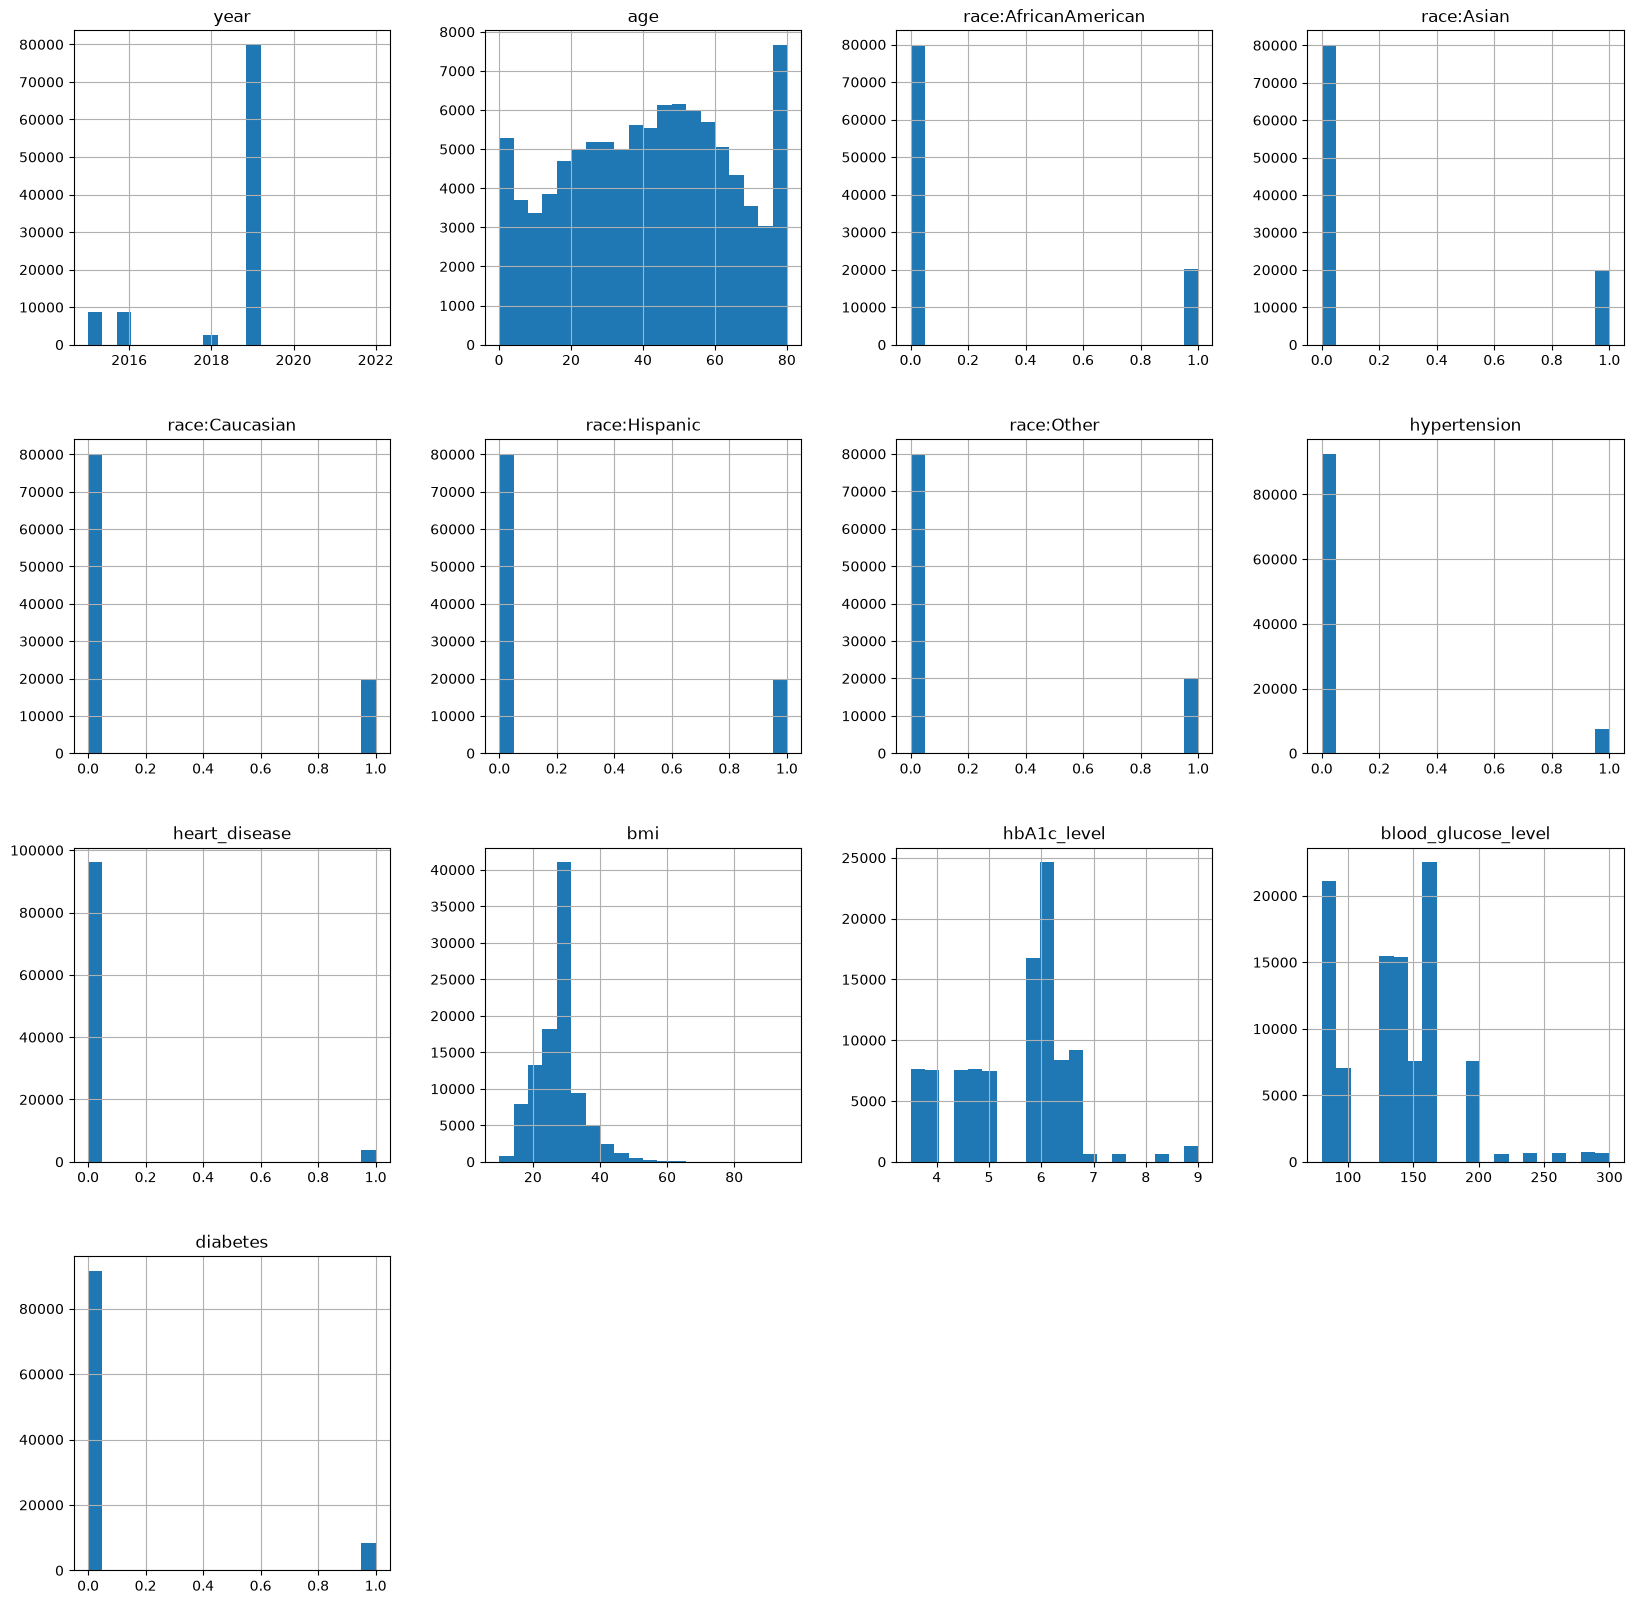

In [22]:
diabetes.hist(bins = 20,
              figsize = (20, 20));